In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
%pip install numpy
%pip install pandas
%pip install pytest
%pip install jinja2

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python3 -m pip install --upgrad

## Statistics: Annual total, mean, wettest/driest month, and coefficient of variation

In [3]:
import numpy
import pandas

from src.region import Region

# rain distribution is by Month [January, February, ...] so first month in position 0 is january
# months = ["January","February","March","April","May","June","July","August","September","October","November","December"]

Kampala = [120, 140, 180, 200, 220, 180,  90,  70,  60, 100, 110, 130]
Gulu    = [  8,  25,  75, 160, 190, 145, 170, 215, 175, 150,  60,  15]
Mbarara = [ 70,  85, 120, 140,  90,  25,  20,  55, 100, 125, 120,  90]
# {'maize': [125,150], 'beans': [100,165], 'coffee':[135,200]}

##Rain fall dictionary
year_2026 = {'Kampala':Kampala, 'Gulu': Gulu, 'Mbarara':Mbarara}

results =[]
for region, rain_data in year_2026.items():
    region_object = Region(numpy.array(rain_data), region)
    results.append({'city':region,
                     'Total Rain(mm)':region_object.annual_total(),
                     'Mean (mm)':region_object.mean(),
                     'Wettest Month':region_object.wettest_month(),
                     'Driest Month':region_object.driest_month(),
                     'coefficient of variance':region_object.co_efficient_of_variation()
                })
pandas.DataFrame(results)

,city,Total Rain(mm),Mean (mm),Wettest Month,Driest Month,coefficient of variance
0,Kampala,1600.0,133.333333,May,September,0.371652
1,Gulu,1388.0,115.666667,August,January,0.614222
2,Mbarara,1040.0,86.666667,April,July,0.424822


## Crop Rule for crops rain fall threshold

<table border="1">
  <caption>Rainfall requirements for maize, beans and coffee in Uganda (mm). Monthly averages are calculated from the source ranges.</caption>
  <tr>
    <th>Crop</th>
    <th>Rainfall range</th>
    <th>Period</th>
    <th>Average per month (calculated)</th>
    <th>Source</th>
  </tr>
  <tr>
    <td>Maize</td>
    <td>500–600 mm (optimal)</td>
    <td>Per season (~4 months), well distributed</td>
    <td>125–150 mm</td>
    <td>MAAIF, Maize Training Manual for Extension Workers in Uganda<br>
      <a href="https://agriculture.go.ug/wp-content/uploads/2026/01/maize_manual.pdf">https://agriculture.go.ug/wp-content/uploads/2026/01/maize_manual.pdf</a></td>
  </tr>
  <tr>
    <td>Beans</td>
    <td>300–500 mm (FAO; MAAIF gives no mm figure)</td>
    <td>Per season (58–120 days, ~3 months), lighter rain towards the end</td>
    <td>100–165 mm</td>
    <td>MAAIF, Beans Training Manual for Extension Workers in Uganda<br>
      <a href="https://www.agriculture.go.ug/wp-content/uploads/2019/09/Beans-training-manual-for-extension-workers-in-Uganda.pdf">https://www.agriculture.go.ug/wp-content/uploads/2019/09/Beans-training-manual-for-extension-workers-in-Uganda.pdf</a><br>
      FAO, Crop Information: Bean<br>
      <a href="https://www.fao.org/land-water/databases-and-software/crop-information/bean/en/">https://www.fao.org/land-water/databases-and-software/crop-information/bean/en/</a></td>
  </tr>
  <tr>
    <td>Coffee</td>
    <td>1,200–1,800 mm (at least 900 mm for coffee-banana intercrop)</td>
    <td>Per year, well distributed over 9 months; about 25 mm every 14 days for flowering</td>
    <td>135–200 mm in rainy months (100–150 mm averaged over 12 months)</td>
    <td>UCDA, Robusta Coffee Handbook (2019)<br>
      <a href="https://greeninguganda.com/images/product/coffee/robusta.pdf">https://greeninguganda.com/images/product/coffee/robusta.pdf</a></td>
  </tr>
</table>

In [4]:
from src.crop_rule import CropRule

rows = []
for region, rain_data in year_2026.items():
    cp_obj = CropRule(numpy.array(rain_data), region)
    for month, crops in cp_obj.classify().items():
        rows.append({"region": region, "month": month, **crops})

df = pandas.DataFrame(rows)
df

,region,month,maize,beans,coffee
0,Kampala,January,Drought risk,Good for beans,Drought risk
1,Kampala,February,Good for maize,Good for beans,Good for coffee
2,Kampala,March,Waterlogging risk,Waterlogging risk,Good for coffee
3,Kampala,April,Waterlogging risk,Waterlogging risk,Good for coffee
4,Kampala,May,Waterlogging risk,Waterlogging risk,Waterlogging risk
5,Kampala,June,Waterlogging risk,Waterlogging risk,Good for coffee
6,Kampala,July,Drought risk,Drought risk,Drought risk
7,Kampala,August,Drought risk,Drought risk,Drought risk
8,Kampala,September,Drought risk,Drought risk,Drought risk
9,Kampala,October,Drought risk,Good for beans,Drought risk


## Cosine similarity

In [5]:
import numpy 
from src.crop_rule import CropRule
from scipy.spatial.distance import cosine

mine = Region.cosine_similarity(Kampala, Gulu)
reference  = 1 - cosine(Kampala, Gulu)
print(mine, reference, numpy.isclose(mine, reference))

0.7866089874660105 0.7866089874660105 True


In [6]:
regions = {name: Region(numpy.array(data), name) for name, data in year_2026.items()}
names = list(regions)

def build_matrix(method):
    """Apply a pairwise method to every pair of regions."""
    values = [
        [method(regions[a].rain_fall_data, regions[b].rain_fall_data) for b in names]
        for a in names
    ]
    return pandas.DataFrame(values, index=names, columns=names).round(3)

cosine_matrix    = build_matrix(Region.cosine_similarity)
pearson_matrix   = build_matrix(Region.pearson_correlation)
euclidean_matrix = build_matrix(Region.euclidean_distance)

print("Cosine similarity\n", cosine_matrix, "\n")
print("Pearson correlation\n", pearson_matrix, "\n")
print("Euclidean distance (mm)\n", euclidean_matrix)

Cosine similarity
          Kampala   Gulu  Mbarara
Kampala    1.000  0.787    0.891
Gulu       0.787  1.000    0.749
Mbarara    0.891  0.749    1.000 

Pearson correlation
          Kampala   Gulu  Mbarara
Kampala    1.000 -0.066    0.209
Gulu      -0.066  1.000   -0.174
Mbarara    0.209 -0.174    1.000 

Euclidean distance (mm)
          Kampala     Gulu  Mbarara
Kampala    0.000  315.268    250.4
Gulu     315.268    0.000    312.8
Mbarara  250.400  312.800      0.0


In [7]:
kampala = regions["Kampala"].rain_fall_data
double_kampala = kampala * 2

print("Cosine:   ", Region.cosine_similarity(kampala, double_kampala))   
print("Pearson:  ", Region.pearson_correlation(kampala, double_kampala)) 
print("Euclidean:", Region.euclidean_distance(kampala, double_kampala))  

totals = {name: float(regions[name].rain_fall_data.sum()) for name in names}
print(totals)

Cosine:    1.0
Pearson:   0.9999999999999999
Euclidean: 492.74739979019677
{'Kampala': 1600.0, 'Gulu': 1388.0, 'Mbarara': 1040.0}


**Conclusion**

In this context, using Cosine similarity only checks when rain falls during the year, not how much falls. 
A fake/sample region with double Kampala's rain every month still scores 1.0, which implies a match. 
That's why Kampala (1,600 mm a year) and Mbarara (1,040 mm) score 0.89 even though Kampala is much wetter: both have two rainy seasons at about the same times.

Pearson correlation is better in this regard and gives the same pair just 0.21, but it also ignores the amount of rain.
Only Euclidean distance picks up the difference in amount, putting the doubled region 492.7 mm away from Kampala.

Use cosine or Pearson to compare rainy seasons, and Euclidean distance to compare rainfall amounts.

## Classify each region as unimodal or bimodal

In [8]:
import numpy as np
from scipy.signal import find_peaks

for region, rain_data in year_2026.items():
    cp_obj = CropRule(numpy.array(rain_data), region)
    print(region, cp_obj.rainy_seasons())

Kampala {'region': 'Kampala', 'peak_months': ['May'], 'prominences': [160.0], 'pattern': 'unimodal'}
Gulu {'region': 'Gulu', 'peak_months': ['August'], 'prominences': [207.0], 'pattern': 'unimodal'}
Mbarara {'region': 'Mbarara', 'peak_months': ['April', 'October'], 'prominences': [120.0, 55.0], 'pattern': 'bimodal'}


**Conclusion**

Some places get one rainy season a year. Others get two. 
To check each region, I looked for the months when rain was highest. 
A month only counted as a separate rainy season if the rain dropped clearly before it.

Mbarara has two rainy seasons, one around April and one around October. 
That's what we expect for southwestern Uganda.

Gulu has one long rainy season, peaking in August. 
Rain drops a little in June, but not enough to split it into two seasons. 
That's what we expect for northern Uganda.

Kampala came out with one rainy season, peaking in May. That's wrong, because Kampala usually has two. 
In this data, the rain is low from July to September and then keeps rising all the way to May. There's no real dry break in between, so it looks like one season. The problem is the Kampala numbers, not the method.

## Line chart

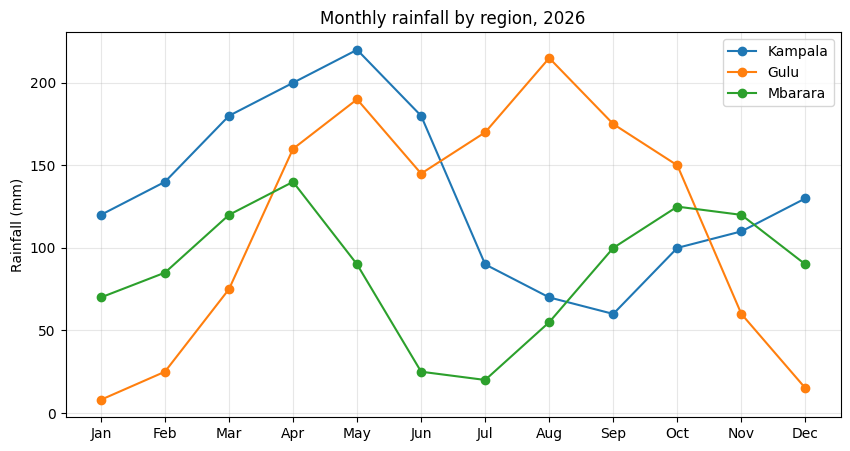

In [9]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

objects = [CropRule(numpy.array(rain), region) for region, rain in year_2026.items()]
short_months = [m[:3] for m in CropRule.months]     # "January" -> "Jan" for the axis

# (a) Line chart of all regions
fig, ax = plt.subplots(figsize=(10, 5))
for obj in objects:
    ax.plot(short_months, obj.rain_fall_data, marker="o", label=obj.region)
ax.set_title(f"Monthly rainfall by region, {objects[0].year}")
ax.set_ylabel("Rainfall (mm)")
ax.legend()
ax.grid(alpha=0.3)
plt.show()


## Heat map

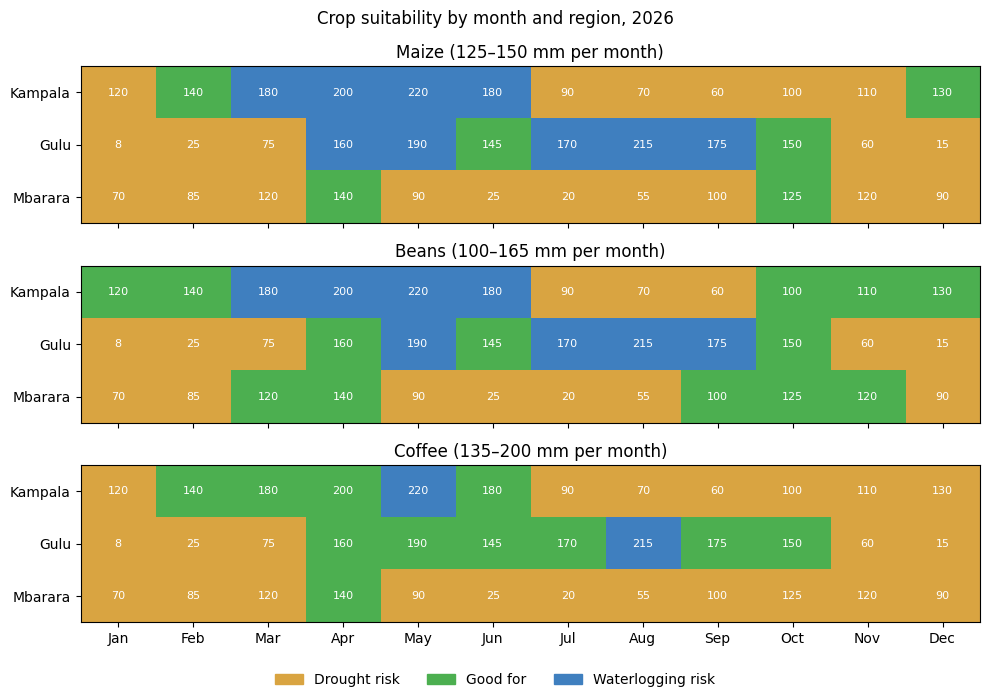

In [10]:
def suitability_code(label: str) -> int:
    """Map a classification label to 0 (drought), 1 (good) or 2 (waterlogging)."""
    if label == CropRule.classification[0]:
        return 0
    if label == CropRule.classification[2]:
        return 2
    return 1        # "Good for maize", "Good for beans", ...

cmap = ListedColormap(["#d9a441", "#4caf50", "#3f7fbf"])   # drought, good, waterlogging
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)
crops = list(CropRule.crop_ranges)
results = {obj.region: obj.classify() for obj in objects}

fig, axes = plt.subplots(len(crops), 1, figsize=(10, 7), sharex=True)
for ax, crop in zip(axes, crops):
    grid = [[suitability_code(results[obj.region][m][crop]) for m in CropRule.months]
            for obj in objects]
    ax.imshow(grid, cmap=cmap, norm=norm, aspect="auto")
    ax.set_yticks(range(len(objects)), [obj.region for obj in objects])
    ax.set_xticks(range(len(short_months)), short_months)
    low, high = CropRule.crop_ranges[crop]
    ax.set_title(f"{crop.capitalize()} ({low}–{high} mm per month)")
    for i, obj in enumerate(objects):
        for j, rain in enumerate(obj.rain_fall_data):
            ax.text(j, i, rain, ha="center", va="center", fontsize=8, color="white")

handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in cmap.colors]
fig.legend(handles, CropRule.classification, loc="lower center", ncol=3, frameon=False)
fig.suptitle(f"Crop suitability by month and region, {objects[0].year}")
fig.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

## Recommendation

Planting advice for Mbarara farmers, 2026

This year, grow beans. Plant them when the rains start in September.

From September to November, Mbarara gets a good amount of rain each month. That is just right for beans. In December the rain gets lighter, which is good, because beans need drier weather when they are ready to harvest.

You can also plant beans in early March. Pick a bean type that grows fast, so you can harvest before the rain stops in late May.

Do not grow maize this year. Maize needs more rain than Mbarara will get in either season.

Be careful with coffee. Mbarara will get less rain this year than coffee needs, so water young coffee trees when it is dry.

Before you plant, listen for the weather forecast on the radio. Ask your local farming officer which beans grow best in your area

### Findings & Limitations

**Findings.** The three regions differ more in when it rains than in how much. Kampala gets the most rain (1,600 mm), then Gulu (1,388 mm) and Mbarara (1,040 mm), but Gulu's rain is the most uneven (coefficient of variation 0.61) because December to February are almost dry. Beans are the safest crop: their wide range of 100–165 mm a month gives five good months in both Kampala and Mbarara. Maize is the hardest. No region has more than two good maize months, and never two in a row, so none can carry a four-month maize season on rain alone. Gulu suits coffee best, with six good months between April and October. The similarity measures answer different questions. Cosine similarity rates Kampala and Mbarara as close (0.89) because their rain rises and falls at similar times, even though Kampala gets 54% more, so an extension officer should compare timing with Pearson correlation or cosine similarity, and amounts with Euclidean distance (250 mm apart).

**Limitations.** The data covers one illustrative year, so it shows no year-to-year variation, and one bad season could change every recommendation. The monthly crop ranges spread seasonal totals evenly across the months, but crops need different amounts at different stages; beans, for example, need drier weather at harvest. The fixed limits also call 124 mm a drought risk for maize and 125 mm good. The number of rainy seasons depends on the 50 mm prominence threshold: at 45 mm or less Gulu becomes bimodal, and at 60 mm or more Mbarara becomes unimodal. Kampala comes out unimodal because its illustrative data has no dry break, which does not match its real climate. Rainfall is also the only factor considered; soil, temperature and evaporation are ignored.

## Using Real Data from NASA Power

Loading from Files..........
Loading from Files..........
Loading from Files..........


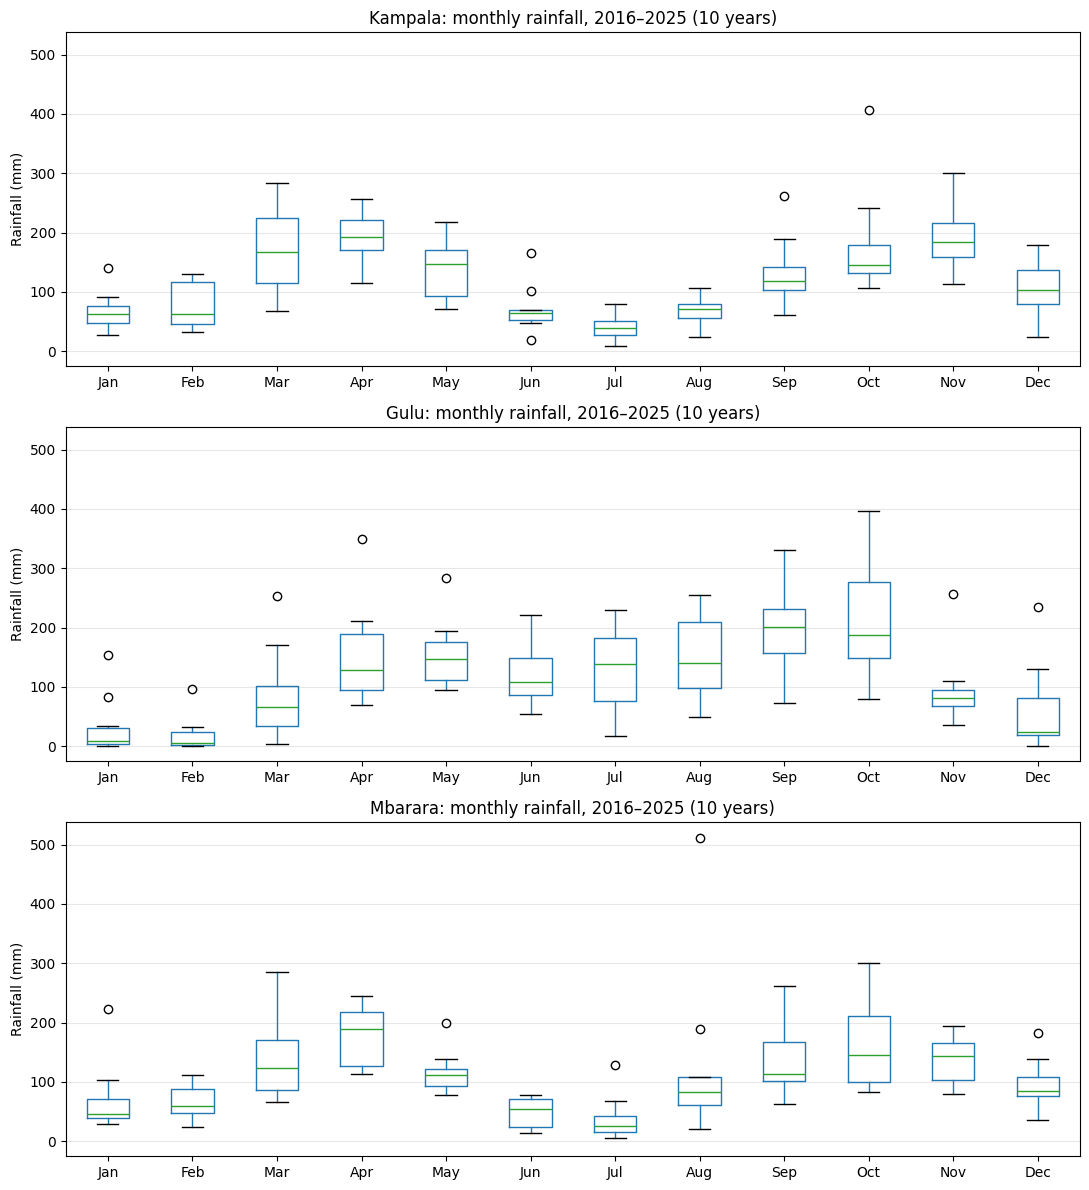

In [11]:
from src.rain_data import RainData
from src.region import Region
import pandas
import matplotlib.pyplot as plt

locations = {
    "Kampala": {"lat": 0.3476, "lon": 32.5825},
    "Gulu":    {"lat": 2.7724, "lon": 32.2881},
    "Mbarara": {"lat": -0.6072, "lon": 30.6545},
}

short_months = [m[:3] for m in Region.months]

rain_tables = {}
for location, cordinates in locations.items():
    rain_data = RainData(location, cordinates)
    df = pandas.DataFrame(rain_data.get()).T 
    df.columns = short_months
    rain_tables[location] = df


fig, axes = plt.subplots(len(rain_tables), 1, figsize=(11, 4 * len(rain_tables)), sharey=True)

for ax, (location, df) in zip(axes, rain_tables.items()):
    df.boxplot(ax=ax, grid=False)
    ax.set_title(f"{location}: monthly rainfall, {df.index.min()}–{df.index.max()} ({len(df)} years)")
    ax.set_ylabel("Rainfall (mm)")
    ax.grid(axis="y", alpha=0.3)

fig.tight_layout()
plt.show()